<a href="https://colab.research.google.com/github/senanurcetin/APTOS-2019-diabetic-retinopathy/blob/main/aptos_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APTOS-2019: a tour of the findings

This notebook walks through what the project found, recomputing each claim from
files versioned in the repository rather than restating it.

**It runs without the dataset.** Everything below the preprocessing section
reads `reports/`, which is committed. If the APTOS images are present under
`data/`, the preprocessing section uses a real fundus photograph; otherwise it
uses a synthetic one with the same geometry.

The earlier version of this notebook depended on a BigQuery project and a Cloud
Storage bucket that no longer exist, called a dataset class with a parameter it
did not have, and never trained anything. It was replaced rather than patched.

## Setup

In [1]:
import json
import os
import pathlib
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy import stats

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # The package, not a copy of it: the notebook runs the same code as the pipeline.
    if not pathlib.Path("APTOS-2019-diabetic-retinopathy").exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/senanurcetin/APTOS-2019-diabetic-retinopathy.git"],
                       check=True)
    os.chdir("APTOS-2019-diabetic-retinopathy")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "."], check=True)
    sys.path.insert(0, "src")

ROOT = pathlib.Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"

# Imported after the setup above on purpose: in Colab the package only exists
# once the repository has been cloned and installed.
from aptos import preprocessing as pp  # noqa: E402

print("repository:", ROOT)

repository: C:\dev\aptos


## 1. Preprocessing, one step at a time

`Read -> quality check -> auto-crop -> CLAHE -> square -> resize`, all from
`aptos.preprocessing` - the same functions the training cache was built with and
the inference service calls.

In [2]:
def synthetic_fundus(h=900, w=1300, seed=0):
    '''A bright textured disc on black, clipped top and bottom by the frame -
    the geometry measured on real APTOS images, which is what makes pad and
    squash differ at all.'''
    rng = np.random.default_rng(seed)
    img = np.zeros((h, w, 3), np.uint8)
    cy, cx, r = h // 2, w // 2, int(h * 0.62)
    yy, xx = np.ogrid[:h, :w]
    disc = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
    base = np.array([40, 80, 170], np.float32)
    shade = 1 - ((yy - cy) ** 2 + (xx - cx) ** 2) / (r ** 2) * 0.5
    tex = rng.normal(1.0, 0.06, (h, w))
    for c in range(3):
        img[..., c] = np.where(disc, np.clip(base[c] * shade * tex, 0, 255), 0)
    for _ in range(40):  # vessel-ish strokes
        p0 = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        p1 = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        cv2.line(img, p0, p1, (20, 30, 90), int(rng.integers(1, 4)))
    img[~disc] = 0
    return img

FORCE_SYNTHETIC = os.environ.get("APTOS_NB_SYNTHETIC") == "1"
raw_dir = ROOT / "data" / "images" / "train_images" / "train_images"
real = sorted(raw_dir.glob("*.png"))[:1] if raw_dir.exists() and not FORCE_SYNTHETIC else []
if real:
    image = cv2.imread(str(real[0]))
    source = f"real image {real[0].name}"
else:
    image = synthetic_fundus()
    source = "synthetic image (dataset not present)"
print("using:", source, image.shape)

using: real image 1ae8c165fd53.png (2136, 3216, 3)


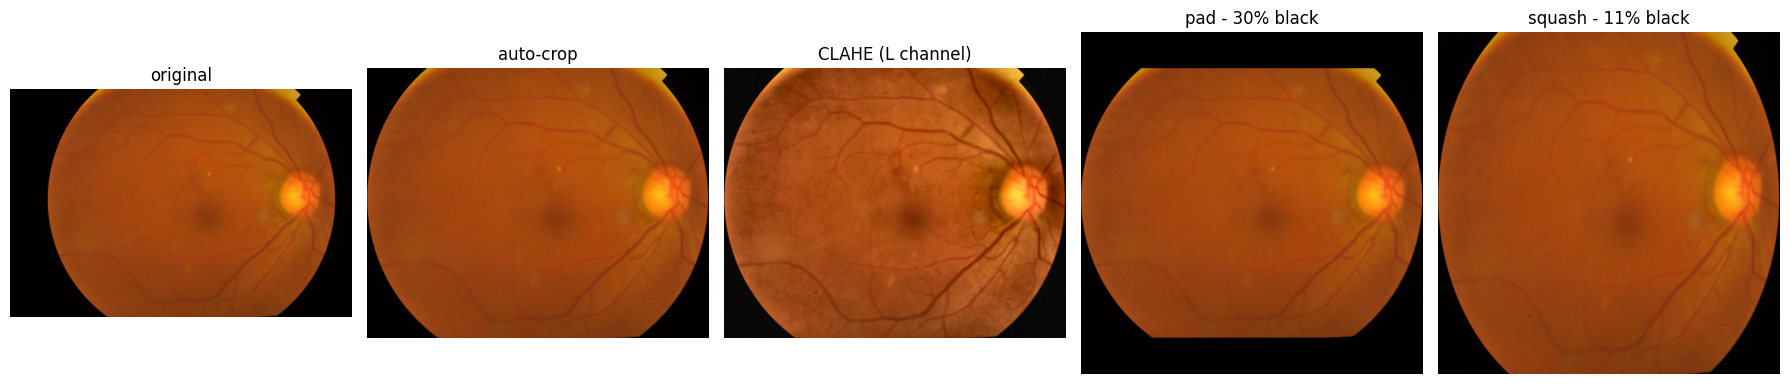

quality gate: pass  brightness=69.4
auto-crop removed 15.7% of the frame


In [3]:
ok, quality = pp.image_quality(image)
cropped = pp.auto_crop(image)
clahe = pp.apply_clahe(cropped, clip_limit=2.0)
padded = pp.to_square(cropped, 512, mode="pad")
squashed = pp.to_square(cropped, 512, mode="squash")

def black_share(img):
    return float((cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) <= 7).mean())

panels = [(image, "original"), (cropped, "auto-crop"), (clahe, "CLAHE (L channel)"),
          (padded, f"pad - {black_share(padded):.0%} black"),
          (squashed, f"squash - {black_share(squashed):.0%} black")]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (img, title) in zip(axes, panels, strict=True):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"quality gate: {'pass' if ok else 'fail'}  brightness={quality['brightness']:.1f}")
print(f"auto-crop removed {1 - cropped.shape[0] * cropped.shape[1] / (image.shape[0] * image.shape[1]):.1%} of the frame")

Squash leaves less black and so carries more retina. That was measured across
the dataset (28.5% black padded against 13.4% squashed) and argued as a reason
to prefer squash. Section 3 shows what training made of the argument.

## 2. The shortcut

A classifier given only file metadata - resolution, aspect ratio, brightness,
file size - reaches QWK 0.652 without seeing a retinal pixel. The numbers below
are read from the generated report, not typed here.

In [4]:
text = (REPORTS / "confounds_and_noise.md").read_text(encoding="utf-8")
for line in text.splitlines():
    if any(key in line for key in ("QWK", "single-label accuracy", "megapixels and")):
        print(line.strip()[:160])

| QWK | **0.6519** | 0.0000 |
This does not invalidate the results, but it does mean **QWK 0.652 is reachable without any diagnosis at all**. Reported scores should be read alongside this fl
`No DR` images have a median of 1.10 megapixels and 50% are square; the diseased grades have medians of 4.2-5.1 megapixels, and at most 5% of any diseased grade
| Estimated single-label accuracy | 84.2% |


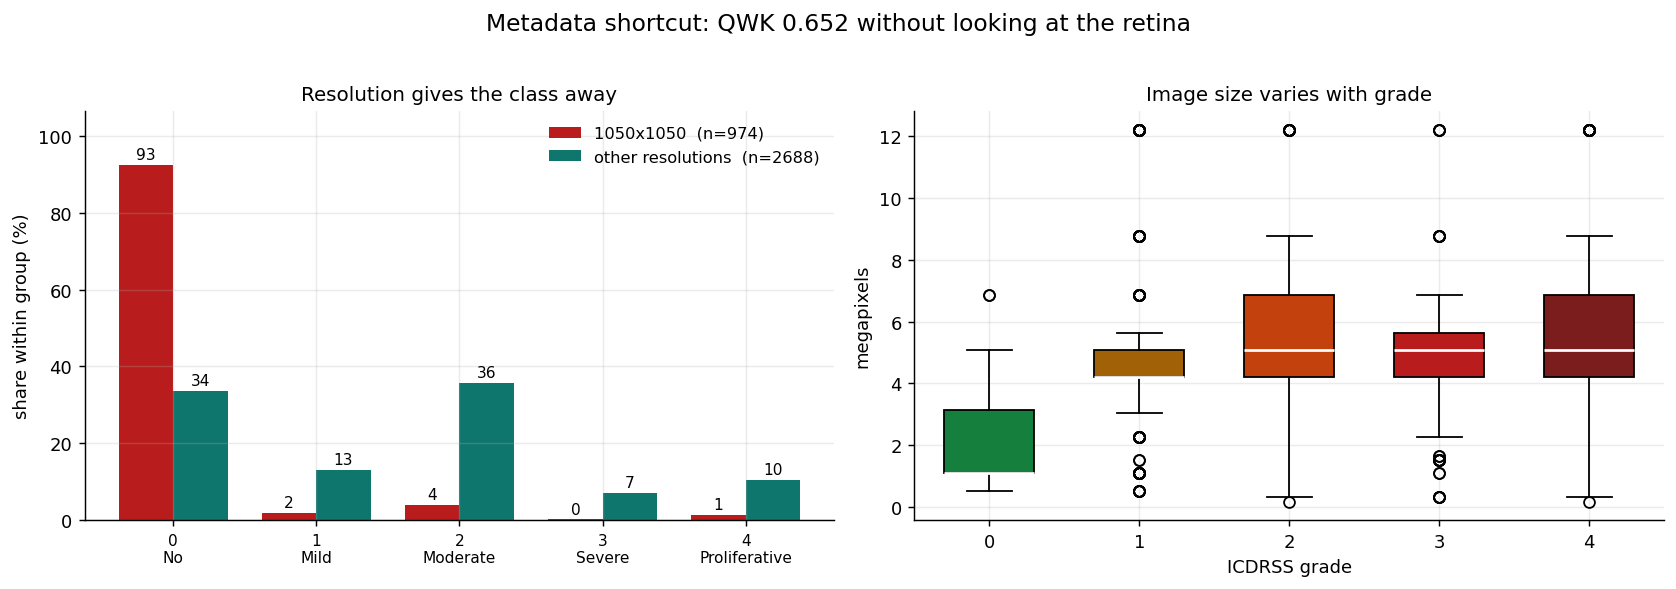

In [5]:
display(Image(filename=str(REPORTS / "figures" / "07_resolution_confound.png"), width=820))

## 3. Cross-validation: two preprocessing ideas, both null

Five folds per variant, the same fold boundaries for all three, so the
comparison is paired. The per-fold test QWK values come from `reports/runs.csv`;
the tests are recomputed here.

In [6]:
runs = pd.read_csv(REPORTS / "runs.csv")
# The variant comparison uses the diagnosis-stratified sweeps. runs.csv also
# holds a resolution-stratified baseline sweep, which answers a different
# question (RESULTS.md, "Across folds") and must not be averaged in here.
runs = runs[runs["stratify"] == "diagnosis"]
folds = (runs[runs["split"] == "cv-fold"]
         .assign(fold=lambda d: d["fold"].astype(int))
         .pivot_table(index="fold", columns="variant", values="test_qwk")
         [["baseline", "squash", "clahe"]])
display(folds.round(4))

rows = []
for variant in ("squash", "clahe"):
    diff = folds[variant] - folds["baseline"]
    rows.append({"comparison": f"{variant} - baseline",
                 "mean diff": diff.mean(), "sd": diff.std(ddof=1),
                 "paired t p": stats.ttest_rel(folds[variant], folds["baseline"]).pvalue,
                 "folds won": f"{int((diff > 0).sum())}/{len(diff)}"})
display(pd.DataFrame(rows).round(4))

variant,baseline,squash,clahe
fold,,,
1,0.8860,0.8805,0.8826
2,0.8882,0.8938,0.8937
3,0.8936,0.8920,0.8923
4,0.8802,0.9018,0.8866
5,0.9030,0.9021,0.8932


,comparison,mean diff,sd,paired t p,folds won
0,squash - baseline,0.0038,0.0107,0.4683,2/5
1,clahe - baseline,-0.0005,0.0067,0.8649,2/5


In [7]:
summaries = runs[runs["split"] == "cv-summary"].set_index("variant")
fold_mean = folds.mean()
ens = summaries["ensemble_qwk"]
table = pd.DataFrame({"fold mean": fold_mean, "ensemble": ens, "ensemble gain": ens - fold_mean})
display(table.round(4))
gap = fold_mean.max() - fold_mean.min()
gain = ens - fold_mean
print(f"largest gap between variants:  {gap:.4f}")
print(f"gain from ensembling, baseline: {gain['baseline']:.4f}  ({gain['baseline'] / gap:.1f}x the gap)")
print(f"gain from ensembling, range:    {gain.min():.4f} - {gain.max():.4f}")

,fold mean,ensemble,ensemble gain
variant,,,
baseline,0.8902,0.9091,0.0189
clahe,0.8897,0.8965,0.0068
squash,0.8940,0.9098,0.0157


largest gap between variants:  0.0044
gain from ensembling, baseline: 0.0189  (4.3x the gap)
gain from ensembling, range:    0.0068 - 0.0189


Neither variant beats the control. For the baseline, ensembling the folds is
worth about four times the largest gap between variants; for clahe the gain is
much smaller, so the comparison is specific to each variant rather than a rule.

## 4. Does the model read the retina? External validation on IDRiD

IDRiD has a single resolution, so the metadata shortcut is unavailable there,
and the prior attached to that resolution is inverted. A prediction was written
down before the run (`docs/external-validation-prediction.md`): a
shortcut-dependent model would over-call disease and specificity would collapse.

In [8]:
ext = json.loads((REPORTS / "external_validation.json").read_text())
cal = json.loads((REPORTS / "calibration.json").read_text())
applied = {row["set"]: row for row in cal["applied"]}

display(pd.DataFrame({
    "APTOS test": {"referable ROC AUC": applied["APTOS test"]["ROC AUC"],
                   "specificity at the chosen cut": applied["APTOS test"]["specificity"],
                   "sensitivity at the chosen cut": applied["APTOS test"]["sensitivity"]},
    "IDRiD": {"referable ROC AUC": applied["IDRiD"]["ROC AUC"],
              "specificity at the chosen cut": applied["IDRiD"]["specificity"],
              "sensitivity at the chosen cut": applied["IDRiD"]["sensitivity"]},
}).round(3))
print(f"IDRiD five-way QWK: {ext['qwk']:.4f}   healthy eyes called referable: "
      f"{ext['healthy_called_referable']:.1%}")
print("predicted grade counts:", ext["predicted_distribution"])
print("true grade counts:     ", ext["true_distribution"])

,APTOS test,IDRiD
referable ROC AUC,0.983,0.984
specificity at the chosen cut,0.934,1.000
sensitivity at the chosen cut,0.920,0.816


IDRiD five-way QWK: 0.8045   healthy eyes called referable: 1.6%
predicted grade counts: {'0': 130, '1': 54, '2': 179, '3': 84, '4': 8}
true grade counts:      {'0': 129, '1': 22, '2': 156, '3': 84, '4': 64}


The prediction failed: specificity rose. Discrimination transfers almost exactly
(ROC AUC 0.984 against 0.983); what moves is calibration, so a cut fitted on
APTOS under-refers on IDRiD, and the five-way grade compresses at the top of
the scale.

## 5. What Grad-CAM could not say

Attention maps were measured rather than drawn: the share of heatmap mass inside
the retina over the share of area the retina occupies. With proper controls -
several untrained draws and all five trained folds - trained and untrained
models are indistinguishable, and the five trained folds disagree with each other
as much. The instrument is too noisy here to answer the question, and no heatmap
is offered by the inference service for that reason.

In [9]:
attention = (REPORTS / "attention.md").read_text(encoding="utf-8")
prefixes = ("| weights", "| random", "| imagenet", "| trained")
table_lines = [line for line in attention.splitlines() if line.startswith(prefixes)]
print("\n".join(table_lines))

| weights | draws | images | concentration | spread across draws | range |
| random | 5 | 300 | **0.895** | 0.145 | 0.71-1.06 |
| imagenet | 5 | 243 | **1.088** | 0.242 | 0.73-1.39 |
| trained | 5 | 300 | **0.940** | 0.201 | 0.72-1.11 |


## 6. A second external set, and where the transfer stops

Messidor-2 (France, 1744 images) is graded by a panel of three retina
specialists. The prediction written first expected referable AUC of at least
0.93 (`docs/second-external-validation-prediction.md`).

In [10]:
cal = json.loads((REPORTS / "calibration.json").read_text())
applied = {row["set"]: row for row in cal["applied"]}
display(pd.DataFrame({name: {"referable ROC AUC": applied[name]["ROC AUC"],
                             "sensitivity at the APTOS cut": applied[name]["sensitivity"],
                             "specificity at the APTOS cut": applied[name]["specificity"]}
                      for name in ("APTOS test", "IDRiD", "Messidor-2")}).round(3))
messidor = json.loads((REPORTS / "external_validation_messidor2.json").read_text())
print("Messidor-2 recall by true grade:", {g: round(r, 3) for g, r in messidor["per_class_recall"].items()})

,APTOS test,IDRiD,Messidor-2
referable ROC AUC,0.983,0.984,0.819
sensitivity at the APTOS cut,0.920,0.816,0.260
specificity at the APTOS cut,0.934,1.000,0.991


Messidor-2 recall by true grade: {'0': 0.93, '1': 0.063, '2': 0.167, '3': 0.173, '4': 0.057}


The prediction failed. The loss sits at grade 2, Moderate: most Moderate eyes
are graded below the referral line. Recalibrating at one new site does not
carry to the next either:

In [11]:
display(pd.DataFrame(cal["transfer"]).round(3))

,fitted on,applied to,ece_aptos_calibrator,ece_refitted,cut_aptos,cut_refitted,sensitivity_aptos_cut,sensitivity_refitted_cut,specificity_aptos_cut,specificity_refitted_cut
0,IDRiD,Messidor-2,0.152,0.097,1.336,1.082,0.260,0.341,0.991,0.988
1,Messidor-2,IDRiD,0.117,0.095,1.336,0.202,0.816,0.997,1.000,0.132


## 7. The cause, tested

The reading after Messidor-2 was that the model learned where APTOS's single
graders draw the Mild/Moderate line. That was tested with predictions written
first (`docs/finetune-prediction.md`): fine-tune on half of Messidor-2 with the
panel's grades, and - as a control - on the same images with the model's own
grades.

In [12]:
ft = json.loads((REPORTS / "finetune_messidor2.json").read_text())
rows = {}
for arm in ("none", "adjudicated", "control"):
    m = ft[arm]["Messidor-2 test half"]
    rows[arm] = {"Messidor-2 test AUC": m["referable_auc"],
                 "Moderate graded below 2": m["moderate_below_2"],
                 "IDRiD AUC": ft[arm]["IDRiD"]["referable_auc"],
                 "APTOS test AUC": ft[arm]["APTOS test"]["referable_auc"],
                 "APTOS test accuracy": ft[arm]["APTOS test"]["accuracy"]}
display(pd.DataFrame(rows).round(3))

,none,adjudicated,control
Messidor-2 test AUC,0.830,0.925,0.834
Moderate graded below 2,0.784,0.450,0.825
IDRiD AUC,0.984,0.960,0.981
APTOS test AUC,0.983,0.965,0.976
APTOS test accuracy,0.803,0.686,0.776


The adjudicated labels fix it and the control does not, so the failure was the
labels rather than the camera. The fine-tuned model over-grades APTOS, which is
why the deployed model was left unchanged.

## Where to go next

- `docs/WRITEUP.md` - the project in one read
- `RESULTS.md` - every number, with the reasoning and the caveats
- `python -m aptos.pipeline list` - the stage graph that reproduces the reports
- `python scripts/analyze_runs.py --sweep models/cv/<sweep>` - one sweep's errors
- the ONNX export on Hugging Face: `senanurcetin/aptos-retinopathy-grader`
- the live demo: https://aptos-2019-diabetic-retinopathy.onrender.com